# Physical Climate Risk: Tropical Cyclone Trends Affecting Western Australia (1985–2024)

**A repeatable analysis written for AASB S2 physical-risk assessment.** (AASB S2 is the Australian rule that asks big companies to report their climate risks.)

**The question I asked.** Have the tropical cyclones that hit Western Australia grown stronger between 1985 and 2024? And do they track the warming of the sea?

**What I found.** Over this period the seas off WA warmed by about 0.5 °C. That warming is a solid, real trend. What the cyclones did is genuinely ambiguous, and that ambiguity is the finding: whether the storms look weaker or stronger depends on which agency's wind record you use (BOM 10-minute winds drift down, US 1-minute winds drift up, for the same storms), neither WA trend is statistically significant, and once the shared trends are removed there is no year-to-year link between sea warmth and storm strength. The lesson for climate-risk reporting is simple: you cannot guess future cyclone danger from the recent local record, in either direction. You need forward-looking projections instead.

Data: IBTrACS v04r01 (NOAA NCEI), NOAA ERSSTv5, and the Bureau of Meteorology Southern-Hemisphere database. The statistics are coded from scratch in `stats_utils.py` and checked in `test_stats.py`.

In [1]:
import numpy as np, pandas as pd
from pathlib import Path
from IPython.display import Image, display
import analysis  # the four analysis steps, as functions

have_raw = Path('data/raw/ibtracs.SI.list.v04r01.csv').exists()
print('Raw source data present:', have_raw,
      '\n(If False, the notebook runs from the committed cleaned CSVs.)')

Raw source data present: False 
(If False, the notebook runs from the committed cleaned CSVs.)


## 1. Data and cleaning

I load IBTrACS, keep the seasons from 1985–2024, and boil the track points down to one row per storm: peak BOM 10-minute wind, lowest central pressure, peak US 1-minute wind, and how close the storm came to the WA coast. A storm counts as *WA-affecting* if its track passes within 500 km of the coast between the north Kimberley and the Mid West.

**Why I report both wind records.** Different agencies average wind speed over different lengths of time (the US uses 1 minute, BOM uses 10 minutes), so their wind numbers are not the same thing. The BOM value comes out about 12% lower. The two records also disagree on the direction of the intensity trend, as section 3 shows, so leading with either one alone would be choosing the story. I show both and use central pressure (which has no averaging ambiguity) as the tie-breaker.

**Checking the data.** The BOM winds match the Bureau's own database to the knot for the major storms. The 12% US/BOM gap is exactly what the averaging difference predicts. And 97% of the flagged WA storms also show up in the Bureau's Australian database. Within the WA group, the data has a BOM wind figure 92% of the time (85% in the 1980s, rising to 100% in recent years). Across the whole basin, however, BOM winds exist for only about 41% of storms (BOM is the agency for the Australian region only), and that share rises over the decades; the US record covers about 90% of the basin throughout. That coverage difference matters for the basin-wide trends below.

In [2]:
storms = analysis.load_storms()
wa = storms[storms.wa_affecting].copy()
print(f'{len(storms)} South Indian Ocean storms, {len(wa)} WA-affecting, '
      f'seasons {storms.season.min()}-{storms.season.max()}')
display(wa[['season','name','peak_bom_wind_kt','min_bom_pres_hpa',
            'peak_usa_wind_kt','peak_usa_sshs','min_dist_wa_km']].head(10))

758 South Indian Ocean storms, 194 WA-affecting, seasons 1985-2024


,season,name,peak_bom_wind_kt,min_bom_pres_hpa,peak_usa_wind_kt,peak_usa_sshs,min_dist_wa_km
3,1985,Emma,65.0,967.0,45.0,0,47.714392
4,1985,Unnamed,NaN,NaN,35.0,0,497.479865
5,1985,Frank,85.0,950.0,75.0,1,24.036950
9,1985,Gertie,60.0,973.0,55.0,0,7.900612
12,1985,Hubert,80.0,954.0,55.0,0,39.175899
16,1985,Jacob,75.0,950.0,75.0,1,185.982602
18,1985,Kirsty,110.0,920.0,115.0,4,414.331754
19,1985,Lindsay,80.0,950.0,55.0,0,52.155838
20,1985,Sandy,105.0,953.0,120.0,4,10.803148
21,1985,Gretel,50.0,984.0,45.0,0,261.246291


## 2. Frequency and intensity by decade

In a typical season, about five cyclones come within 500 km of WA. On the BOM record their average peak strength has drifted **down** over the four decades (mean BOM wind fell from about 76 kt to 63 kt, and mean pressure rose; a higher pressure means a weaker storm). On the US record the same storms drift **up** (about 65 kt to 75 kt). Hold that contradiction; section 3 tests it formally.

,decade,n_WA,mean_BOM_wind_kt,mean_USA_wind_kt,median_BOM_wind_kt,mean_min_pres_hPa,pct_Cat3plus
0,1985-94,47,75.5,65.4,77.5,959.1,17.0
1,1995-04,55,78.2,79.5,72.5,955.5,38.2
2,2005-14,50,69.1,76.9,65.0,964.3,28.0
3,2015-24,42,63.3,74.7,55.0,972.5,19.0


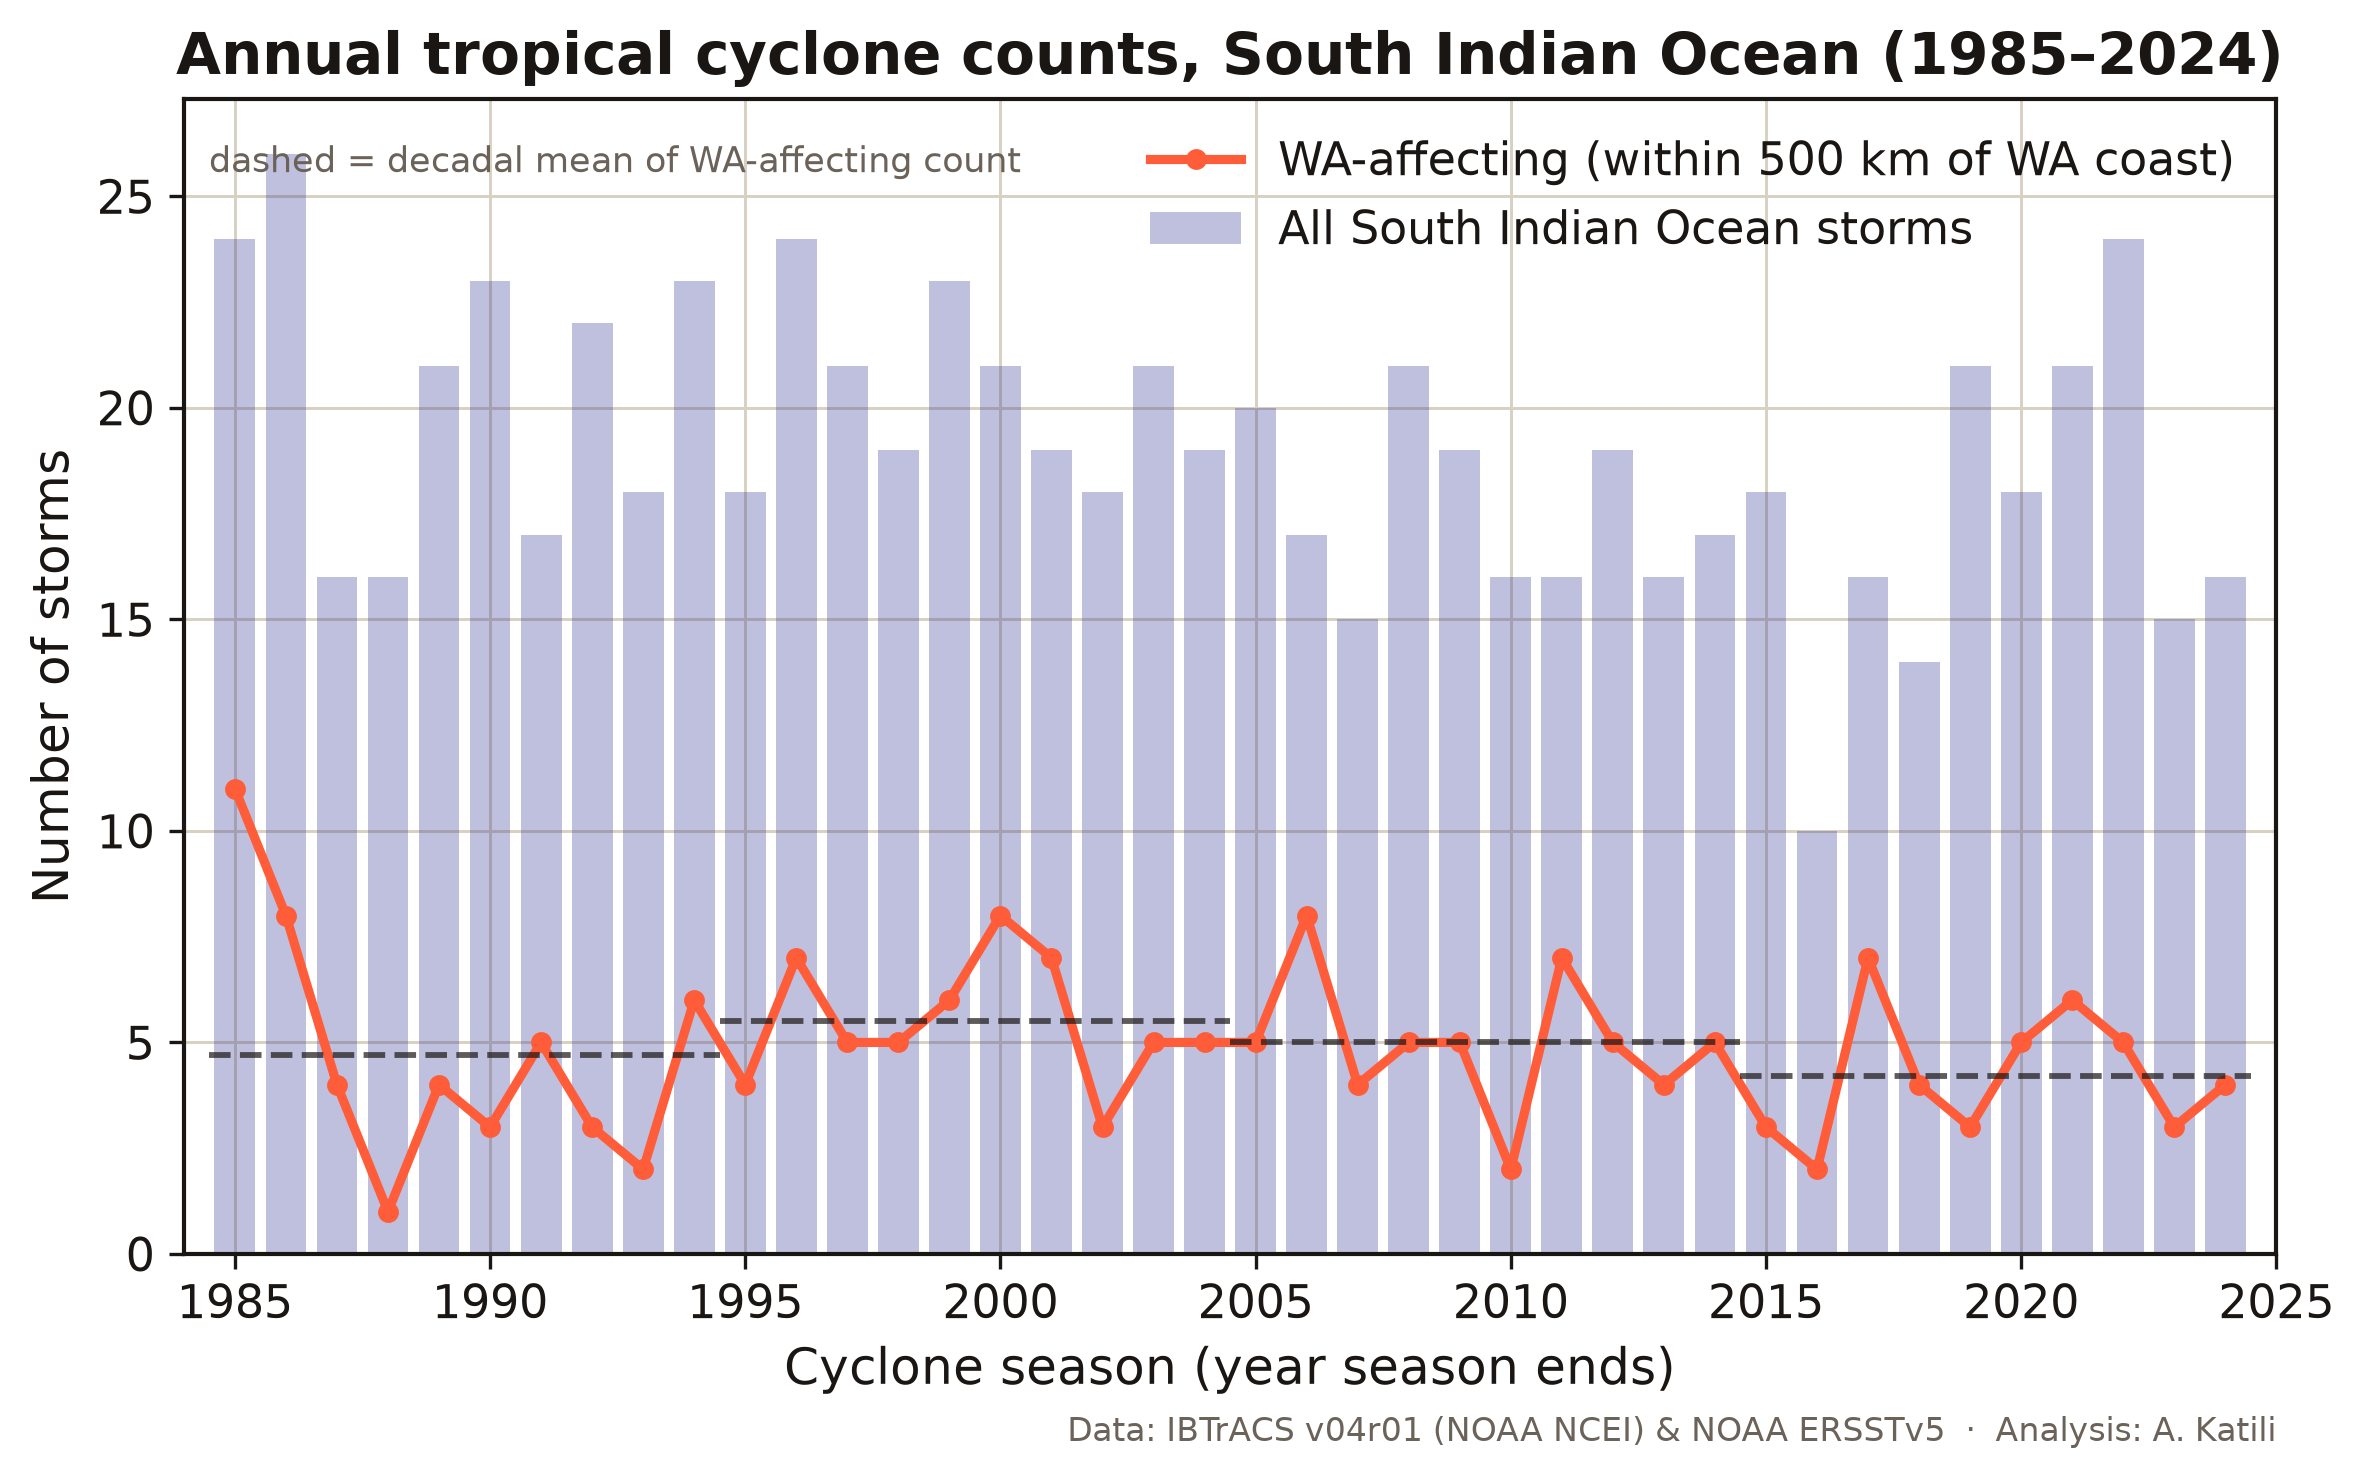

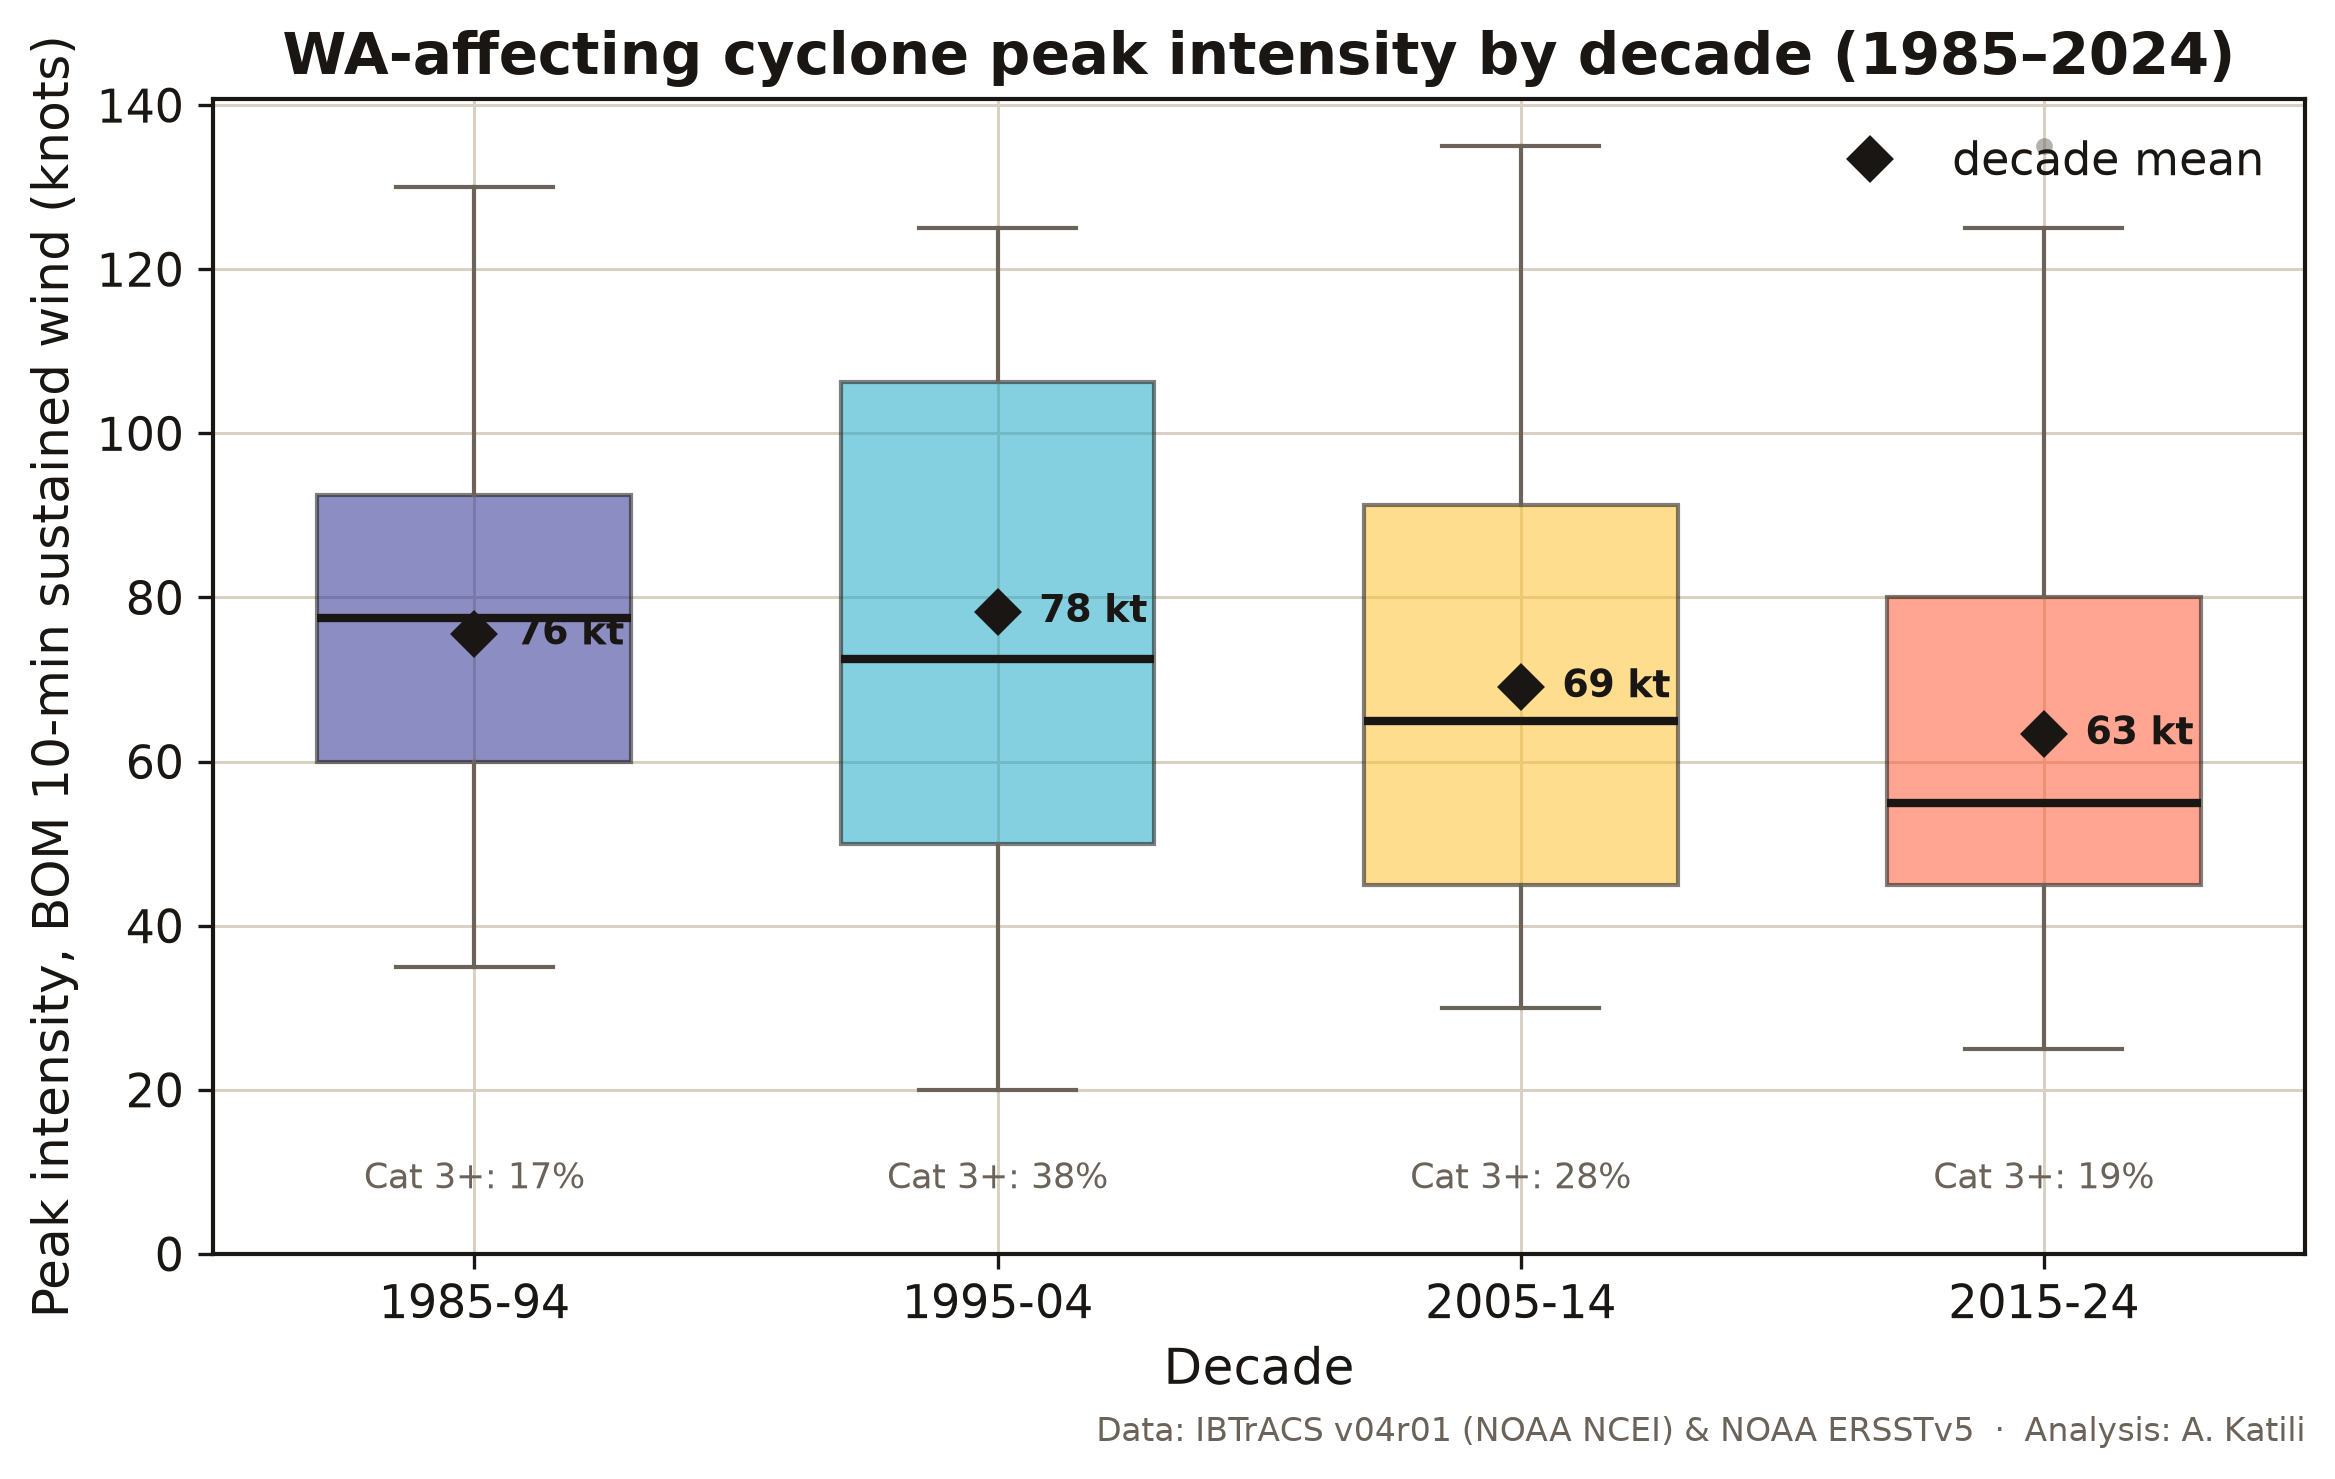

In [3]:
summary, all_count, wa_count = analysis.explore(storms)
display(summary.round(1))
display(Image('charts/01_annual_count.png'))
display(Image('charts/02_intensity_by_decade.png'))

## 3. Trend tests

I test each year-by-year series four ways: ordinary least squares (OLS, the standard straight-line fit) for the slope, Mann-Kendall for whether the trend is real (this is the standard test in climate science), the same Mann-Kendall with trend-free prewhitening (a correction for year-to-year carry-over; it changed nothing here), and Sen's slope for a robust estimate of how big the trend is.

The result is the heart of the project: **the direction of the wind trend depends on which agency's record you use.** BOM 10-minute winds drift down; US 1-minute winds drift up, for the same storms. Within the WA group neither is significant. Basin-wide, both are "significant" and they point in opposite directions, which mostly reflects each record's own problems: the BOM series covers only 41% of basin storms and that subset changes over time, while the US series carries the effect of improving satellite estimation. Central pressure, the cleanest single measure, leans weakly toward weaker WA storms and shows no basin trend at all. The `coverage_pct` column in the table below is the share of storms that have each measurement; treat any series with low coverage with suspicion.

The defensible conclusion is that the observed record does not establish an intensity trend in either direction.

,slope_decade,sen_decade,ols_p,mk_p,mk_p_tfpw,r1,r2,trend,coverage_pct
WA wind (BOM 10-min),-3.571881,-2.922619,0.106511,0.26304,0.26304,-0.131331,0.067104,no trend,91.752577
WA wind (USA 1-min),3.939041,2.81746,0.065889,0.158418,0.158418,-0.023883,0.086238,no trend,90.721649
WA pressure (BOM),4.039995,3.52551,0.042692,0.097968,0.097968,-0.114596,0.103729,no trend,91.752577
Basin wind (BOM 10-min),-3.664706,-3.53836,0.030464,0.047512,0.047512,-0.016915,0.11737,decreasing,40.897098
Basin wind (USA 1-min),3.657398,3.565831,0.001959,0.003197,0.003197,0.049486,0.225521,increasing,90.237467
Basin pressure (WMO),0.712588,0.670272,0.447802,0.616327,0.616327,0.190842,0.015247,no trend,89.44591


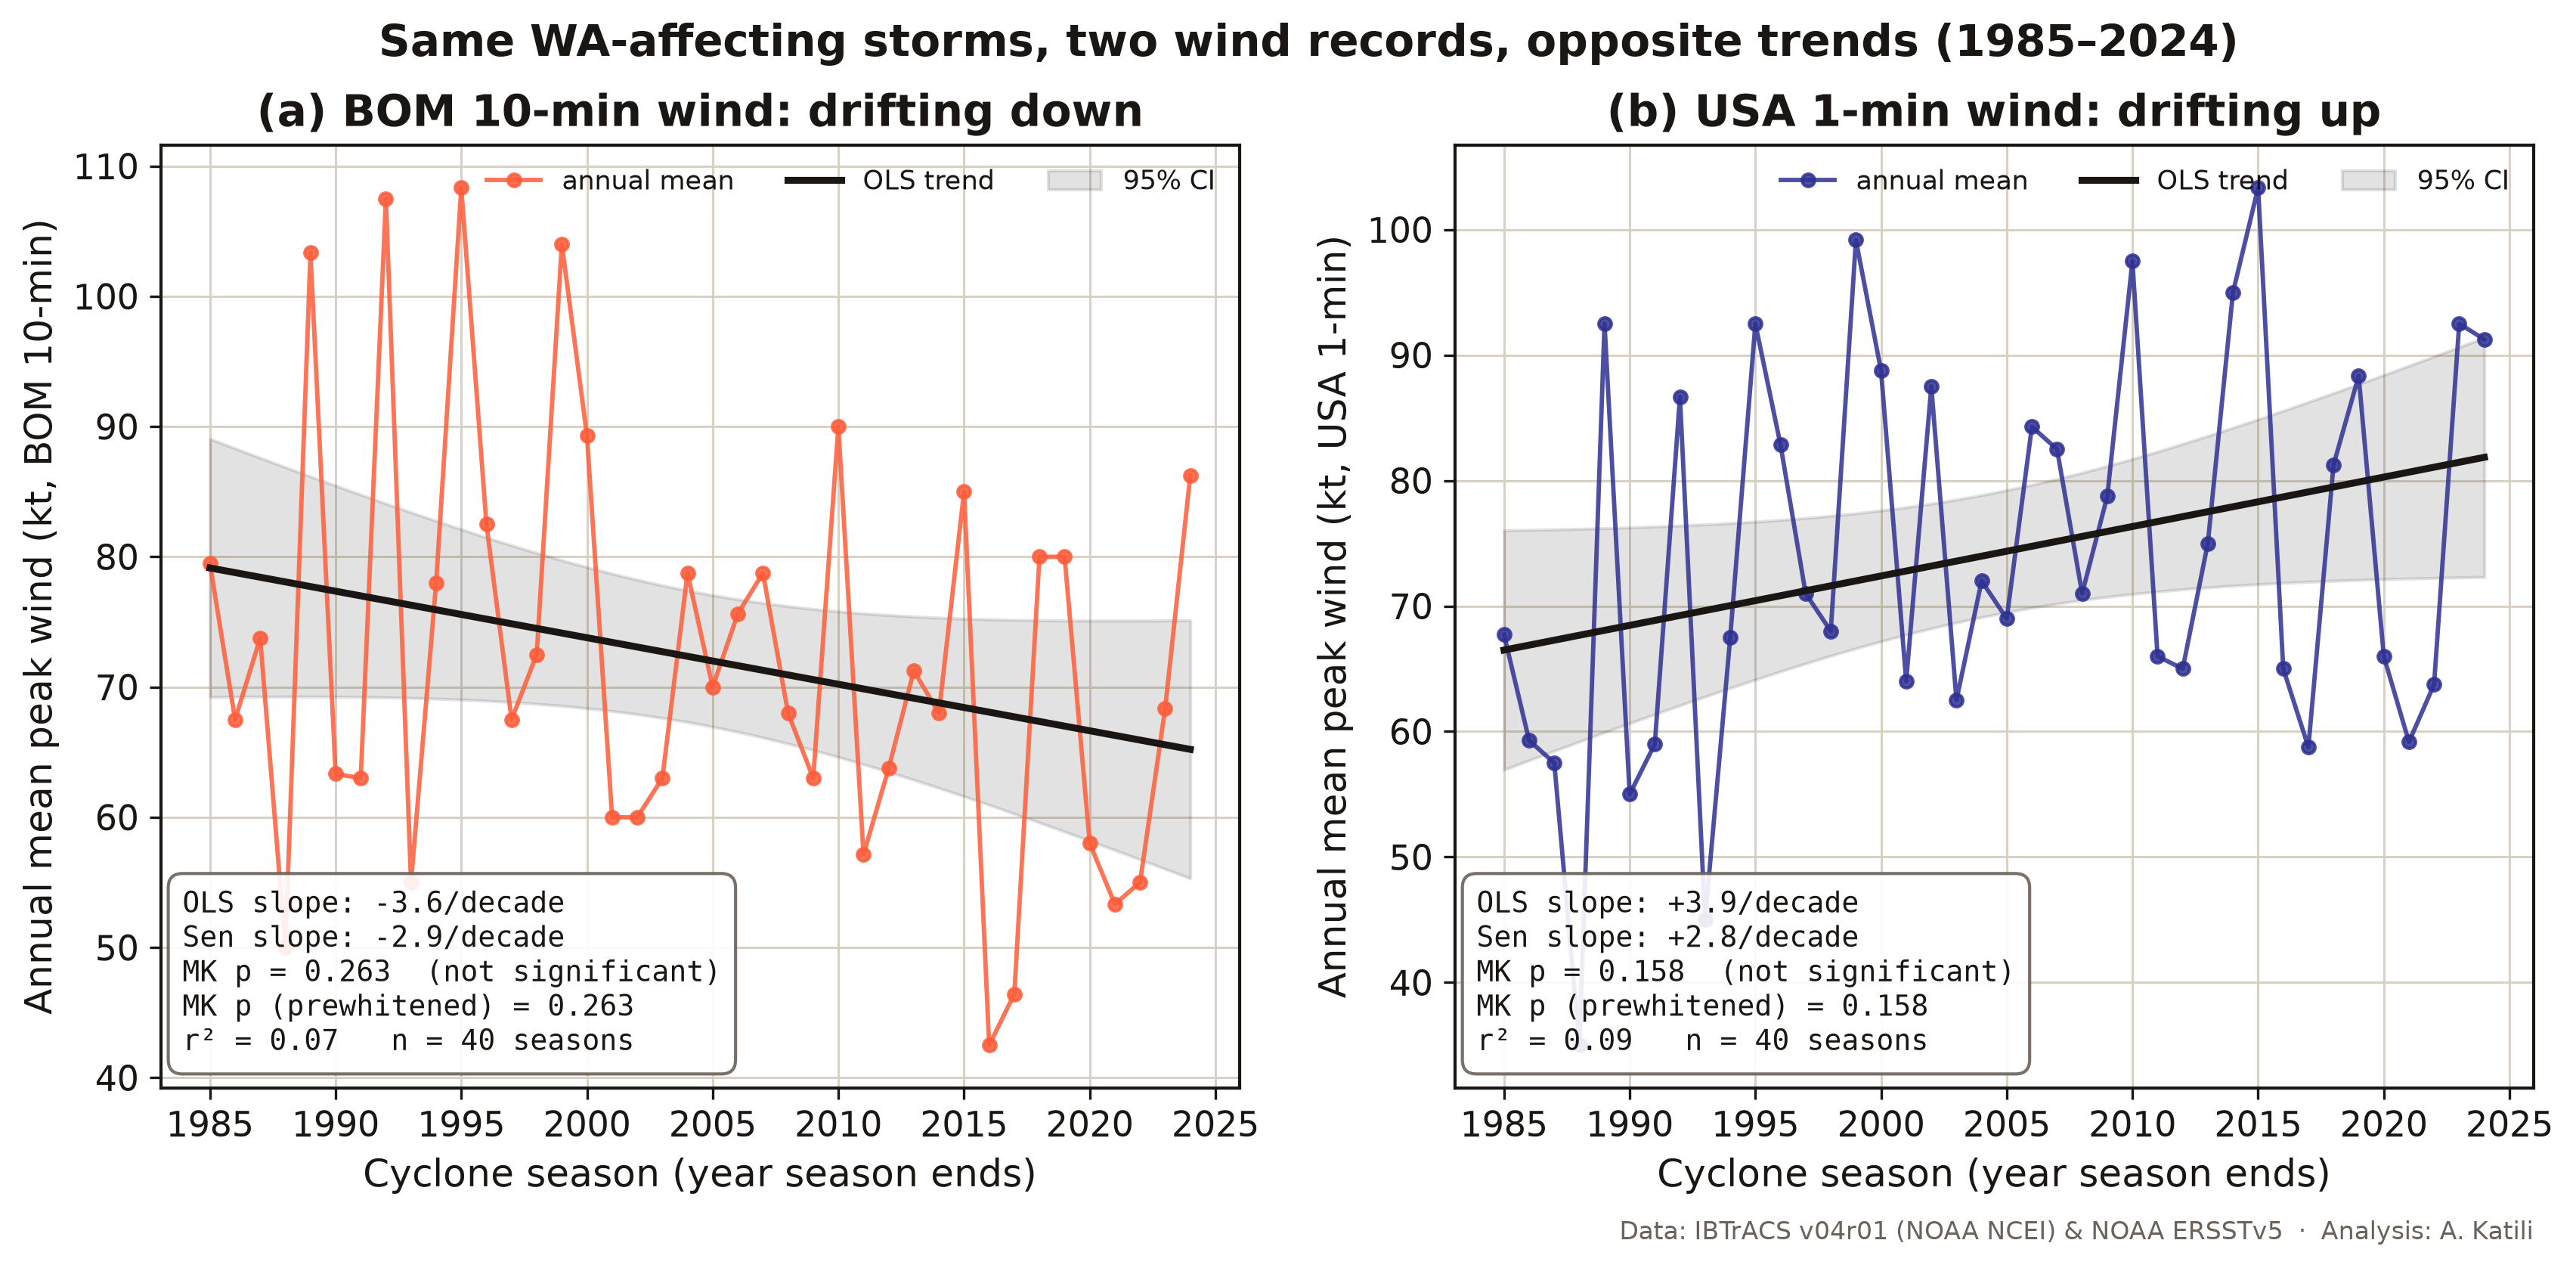

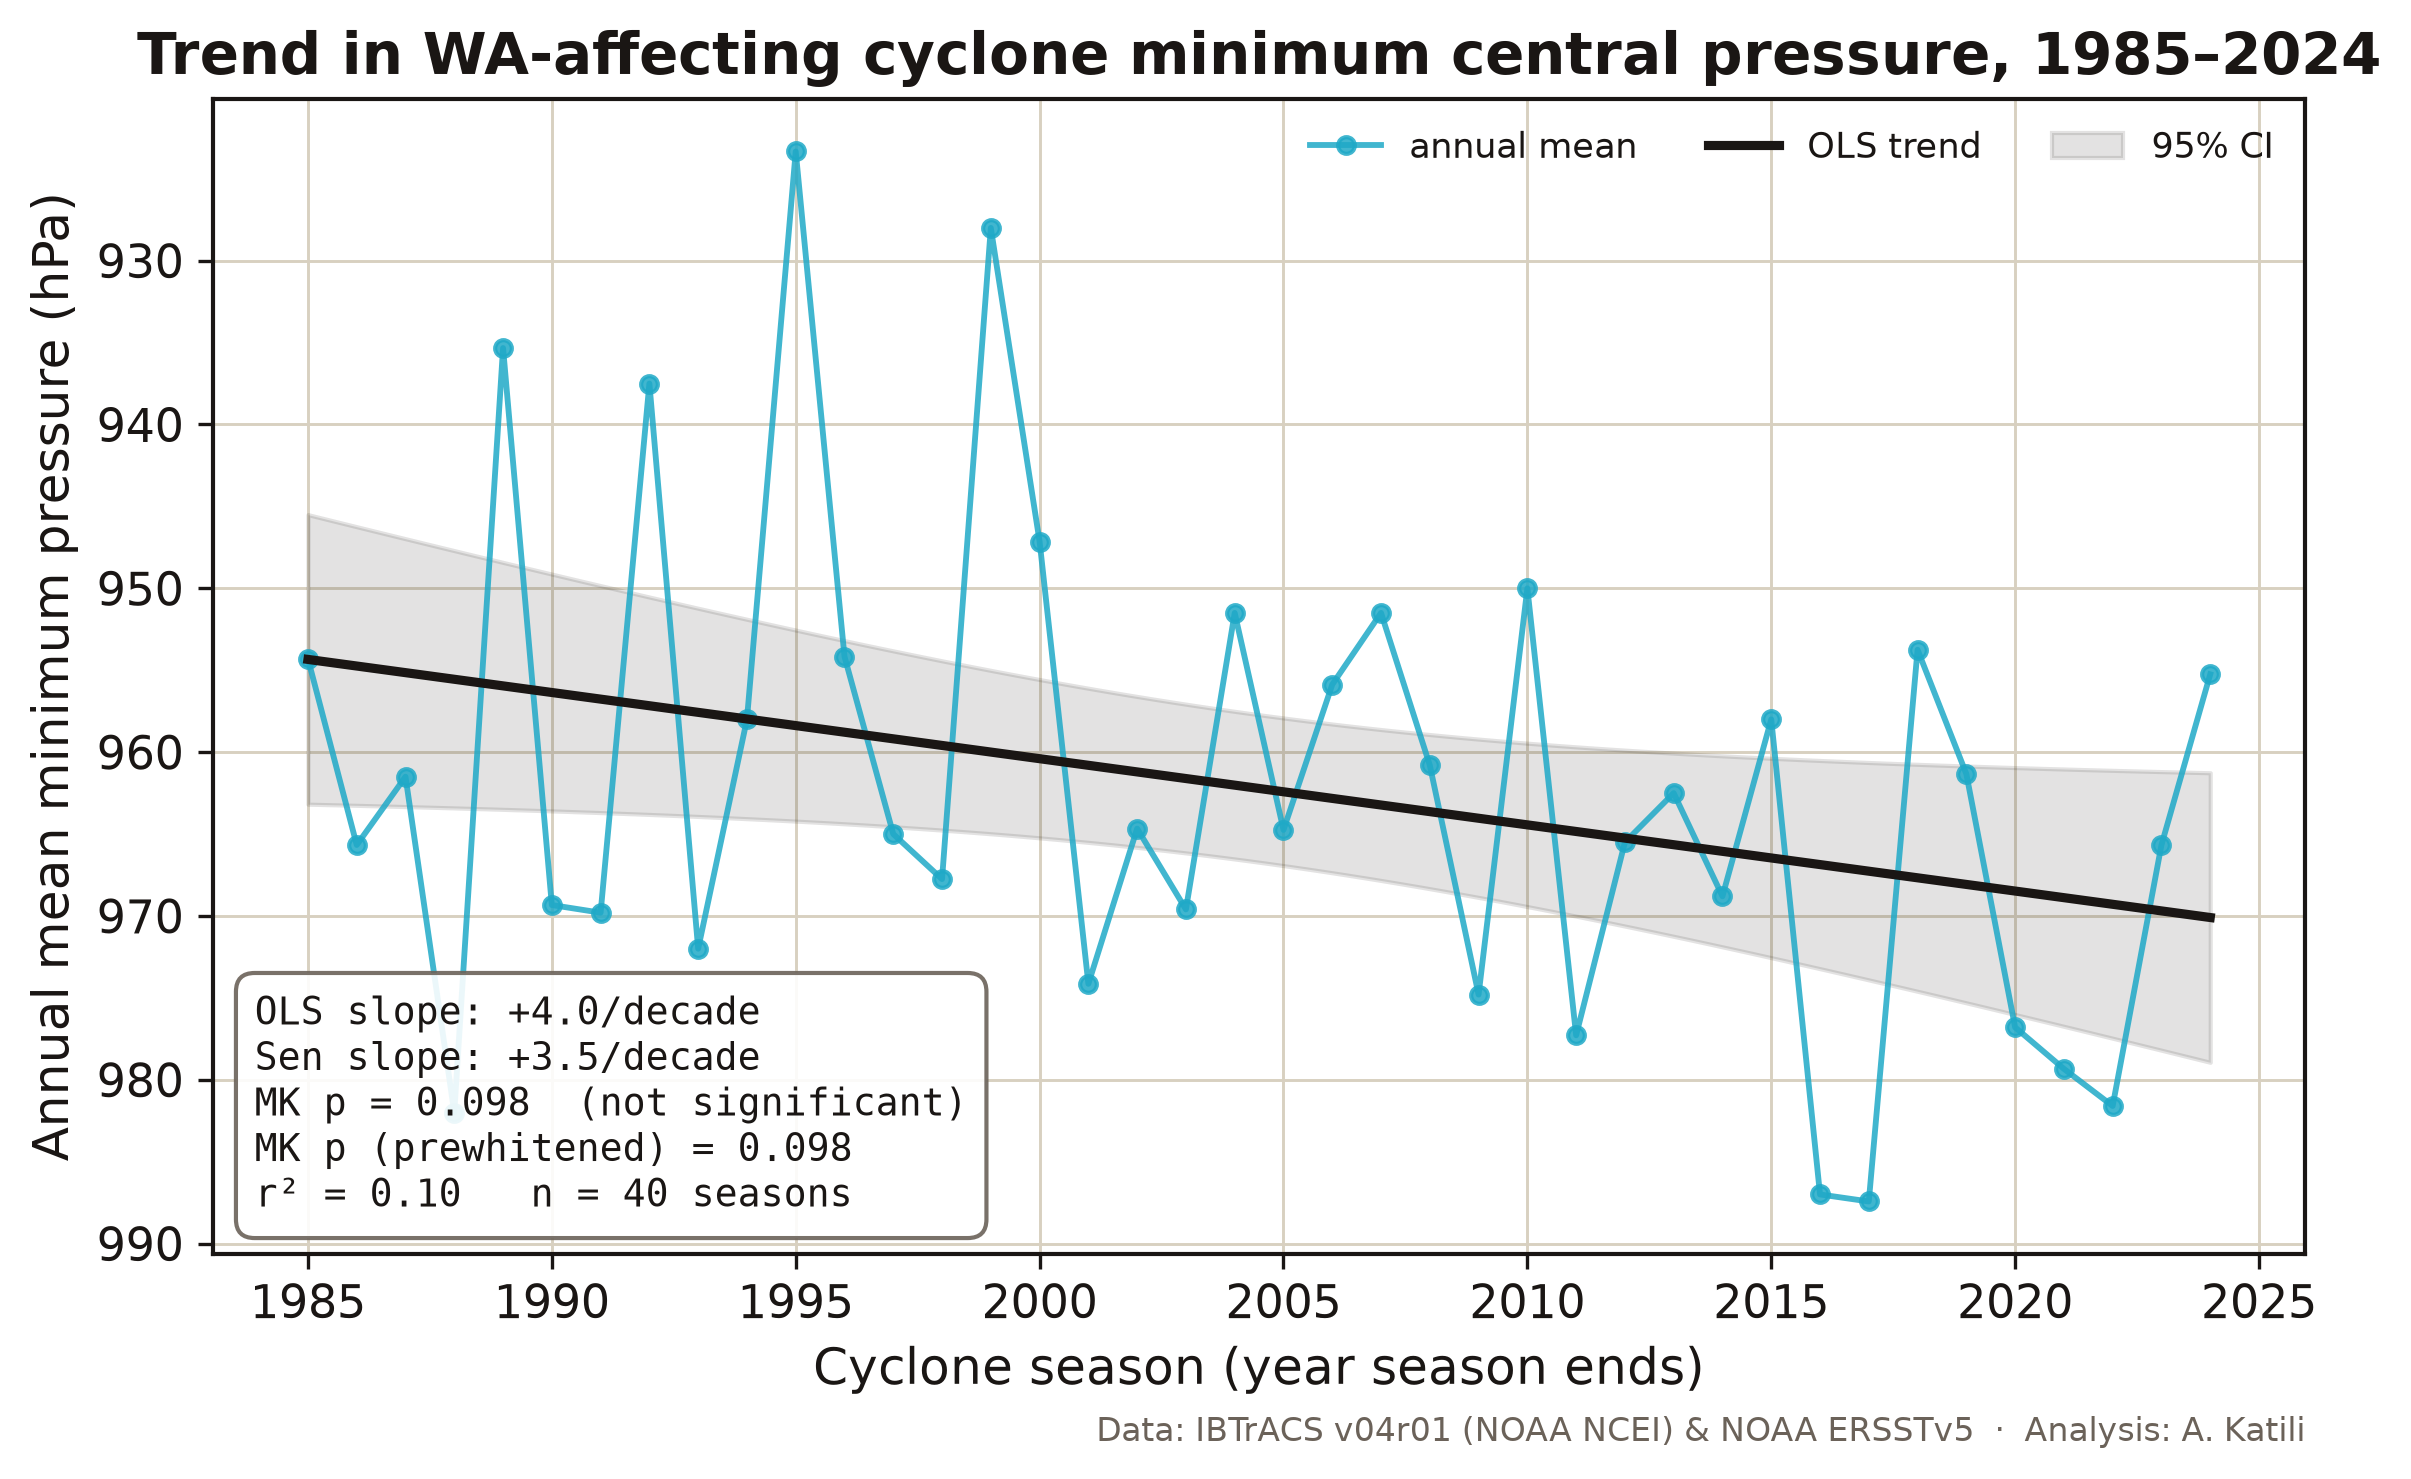

In [4]:
trend_table = analysis.trends(storms)
display(trend_table.round(3))
display(Image('charts/03_trend_wind_speed.png'))
display(Image('charts/04_trend_pressure.png'))

## 4. Rapid intensification

Rapid intensification means a storm gaining at least 30 kt of wind in 24 hours. The share of storms that did this (measured on US 1-minute winds, the usual convention for this metric) rose from about 21% in 1985–94 to around 40% since.

**A caveat I want to be clear about.** Older best-track data is smoother and recorded less often, which by itself makes rapid intensification harder to spot in the early years. So part of the apparent rise is probably an artefact of how storms were observed back then, not a purely physical change. Treat it as suggestive, not proven.

,decade,WA_RI,WA_n,WA_RI_pct,SI_RI,SI_n,SI_RI_pct
0,1985-94,10,47,21.3,51,206,24.8
1,1995-04,24,55,43.6,80,203,39.4
2,2005-14,20,50,40.0,70,176,39.8
3,2015-24,16,42,38.1,72,173,41.6


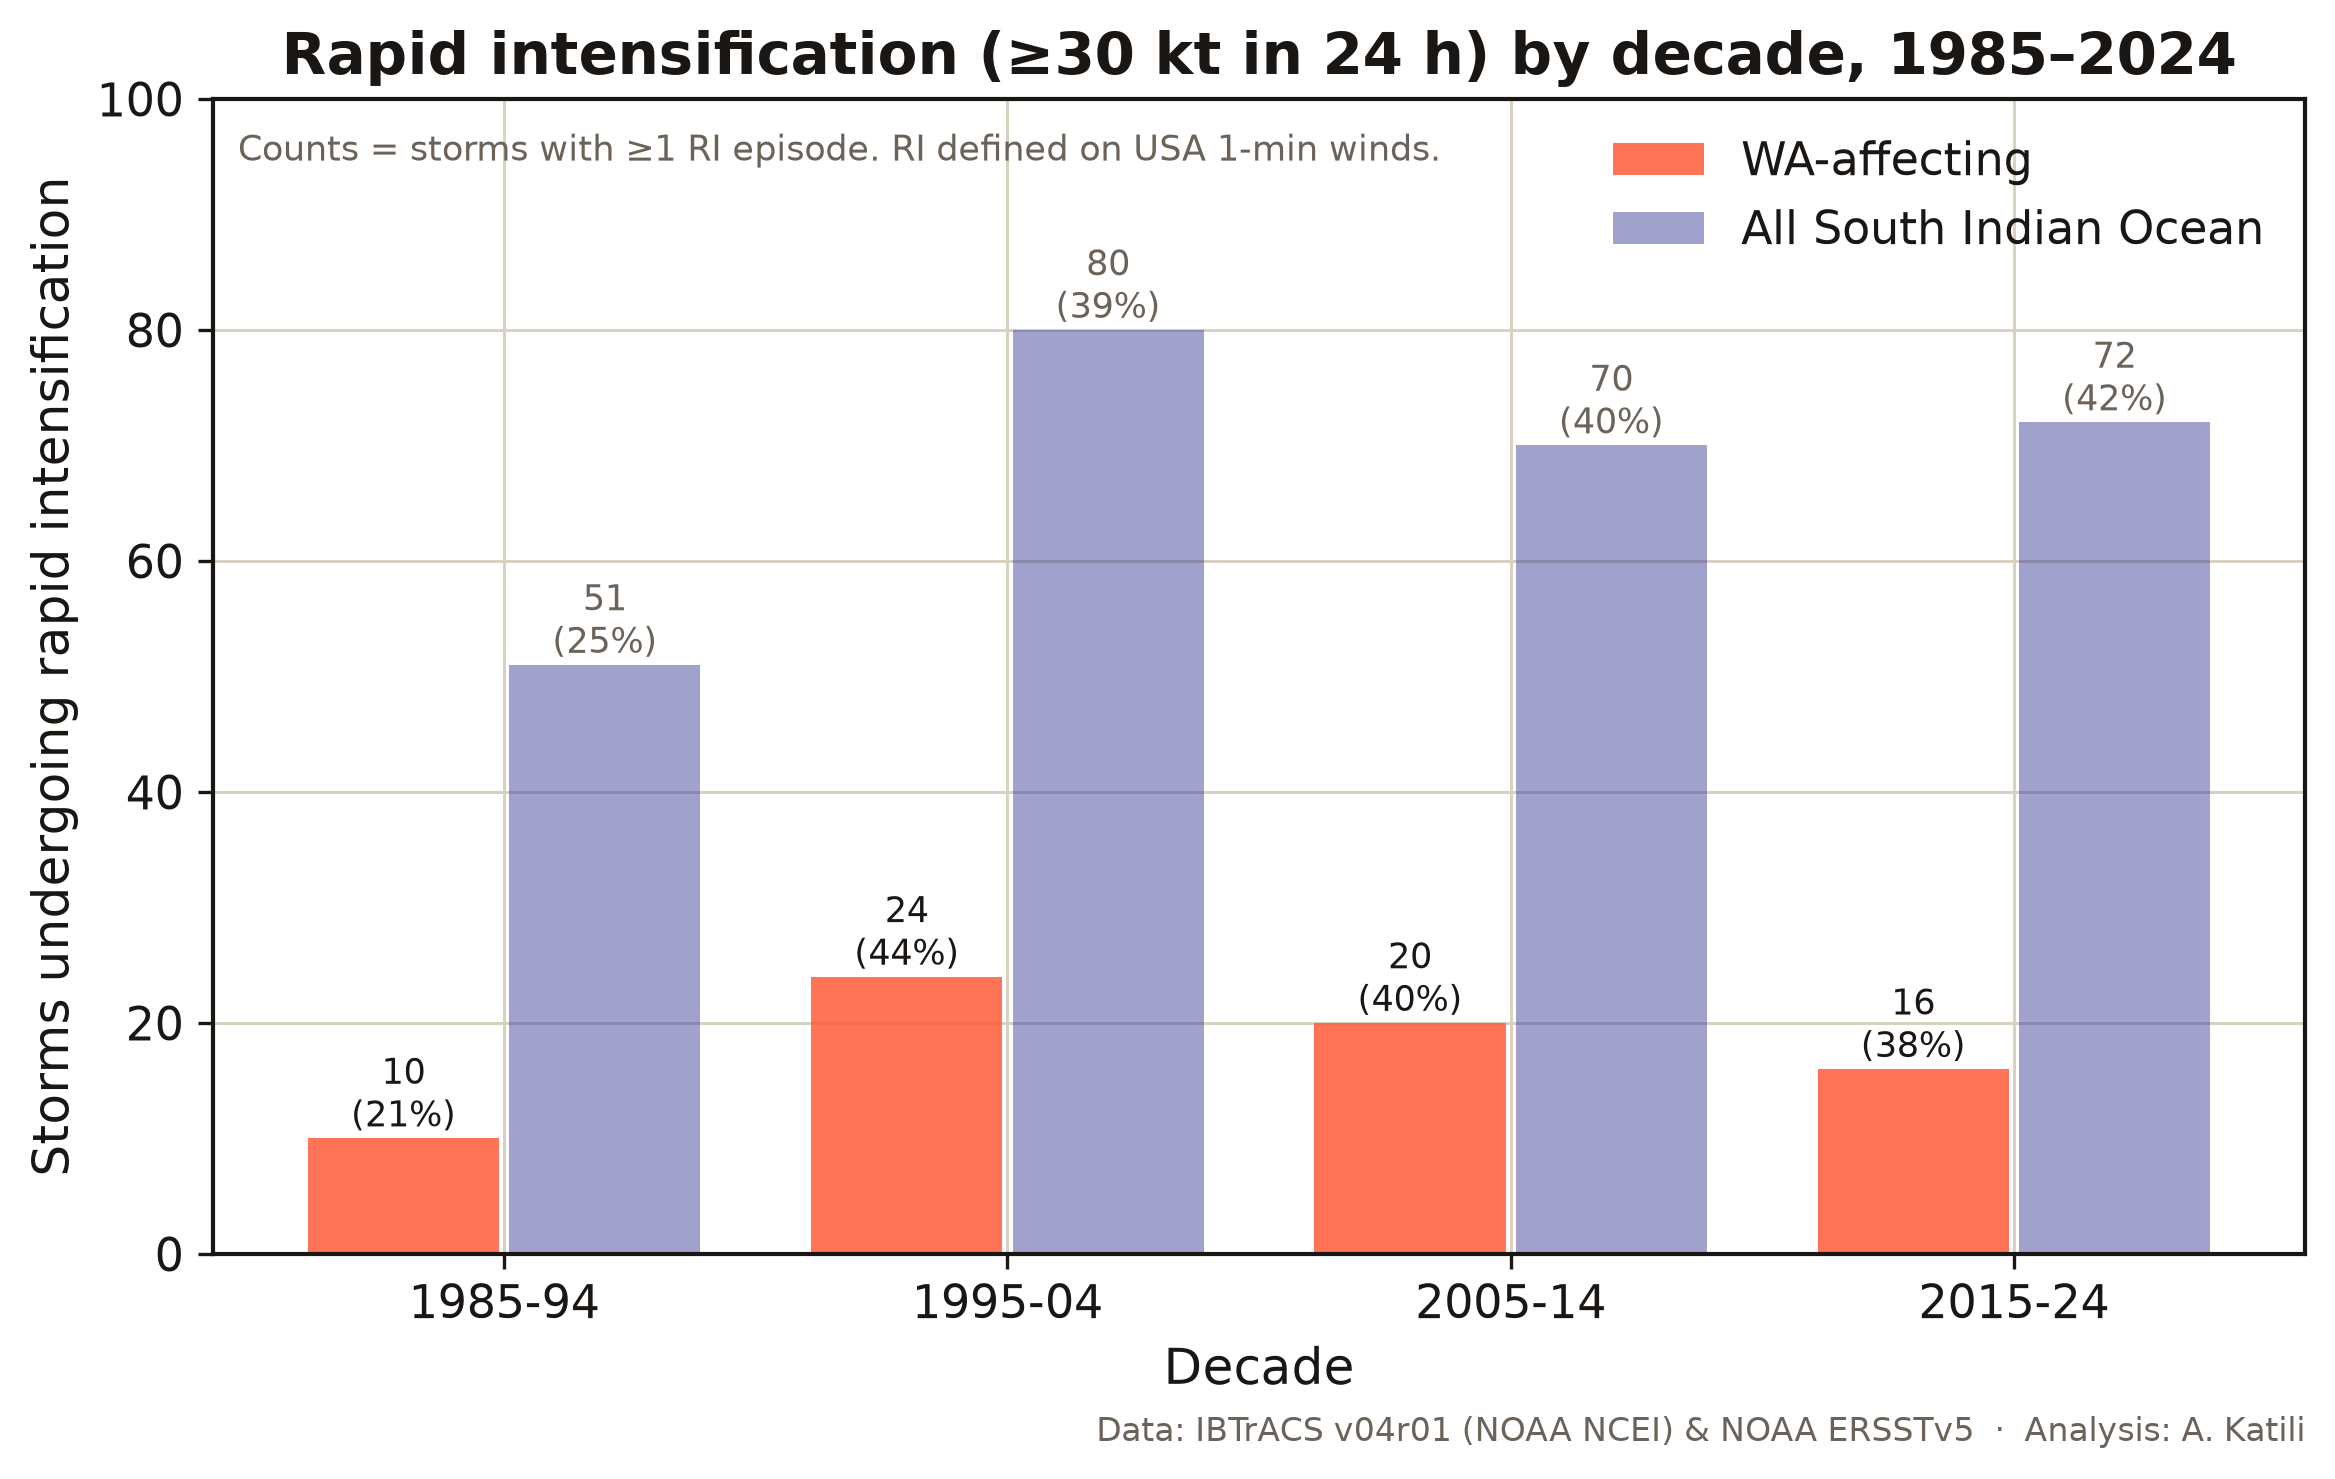

In [5]:
ri_table = analysis.rapid_intensification(storms)
display(ri_table.round(1))
display(Image('charts/05_rapid_intensification.png'))

## 5. Sea-surface temperature

From ERSSTv5 I take the WA cyclone development region (10–30°S, 70–130°E), work out monthly anomalies (how far each month sits above or below normal) against the 1991–2020 average, and take the mean over the Nov–Apr cyclone season. I then check whether that seasonal anomaly lines up with the yearly average strength of WA-affecting storms.

The ocean warmed by a clear, significant amount (about 0.16 °C per decade). Yet warmer seasons were **not** linked to stronger storms. The correlation is reported both raw and detrended: the raw number partly measures the two opposing long-term trends, so the detrended one (the shared drift removed, leaving the year-to-year wobble) is the honest measure of the link, and it is essentially zero. Warm water sets how much energy is on the table, but wind shear (winds changing speed or direction with height, which can tear a storm apart) and the big-picture circulation (ENSO, the Indian Ocean Dipole) decide whether that energy is actually used.

SST trend: +0.161 degC/decade (p=2.3e-05)
SST vs WA wind:     raw r=-0.22 (p=0.173)   detrended r=-0.08 (p=0.628)
SST vs WA pressure: raw r=+0.30 (p=0.058)   detrended r=+0.14 (p=0.392)


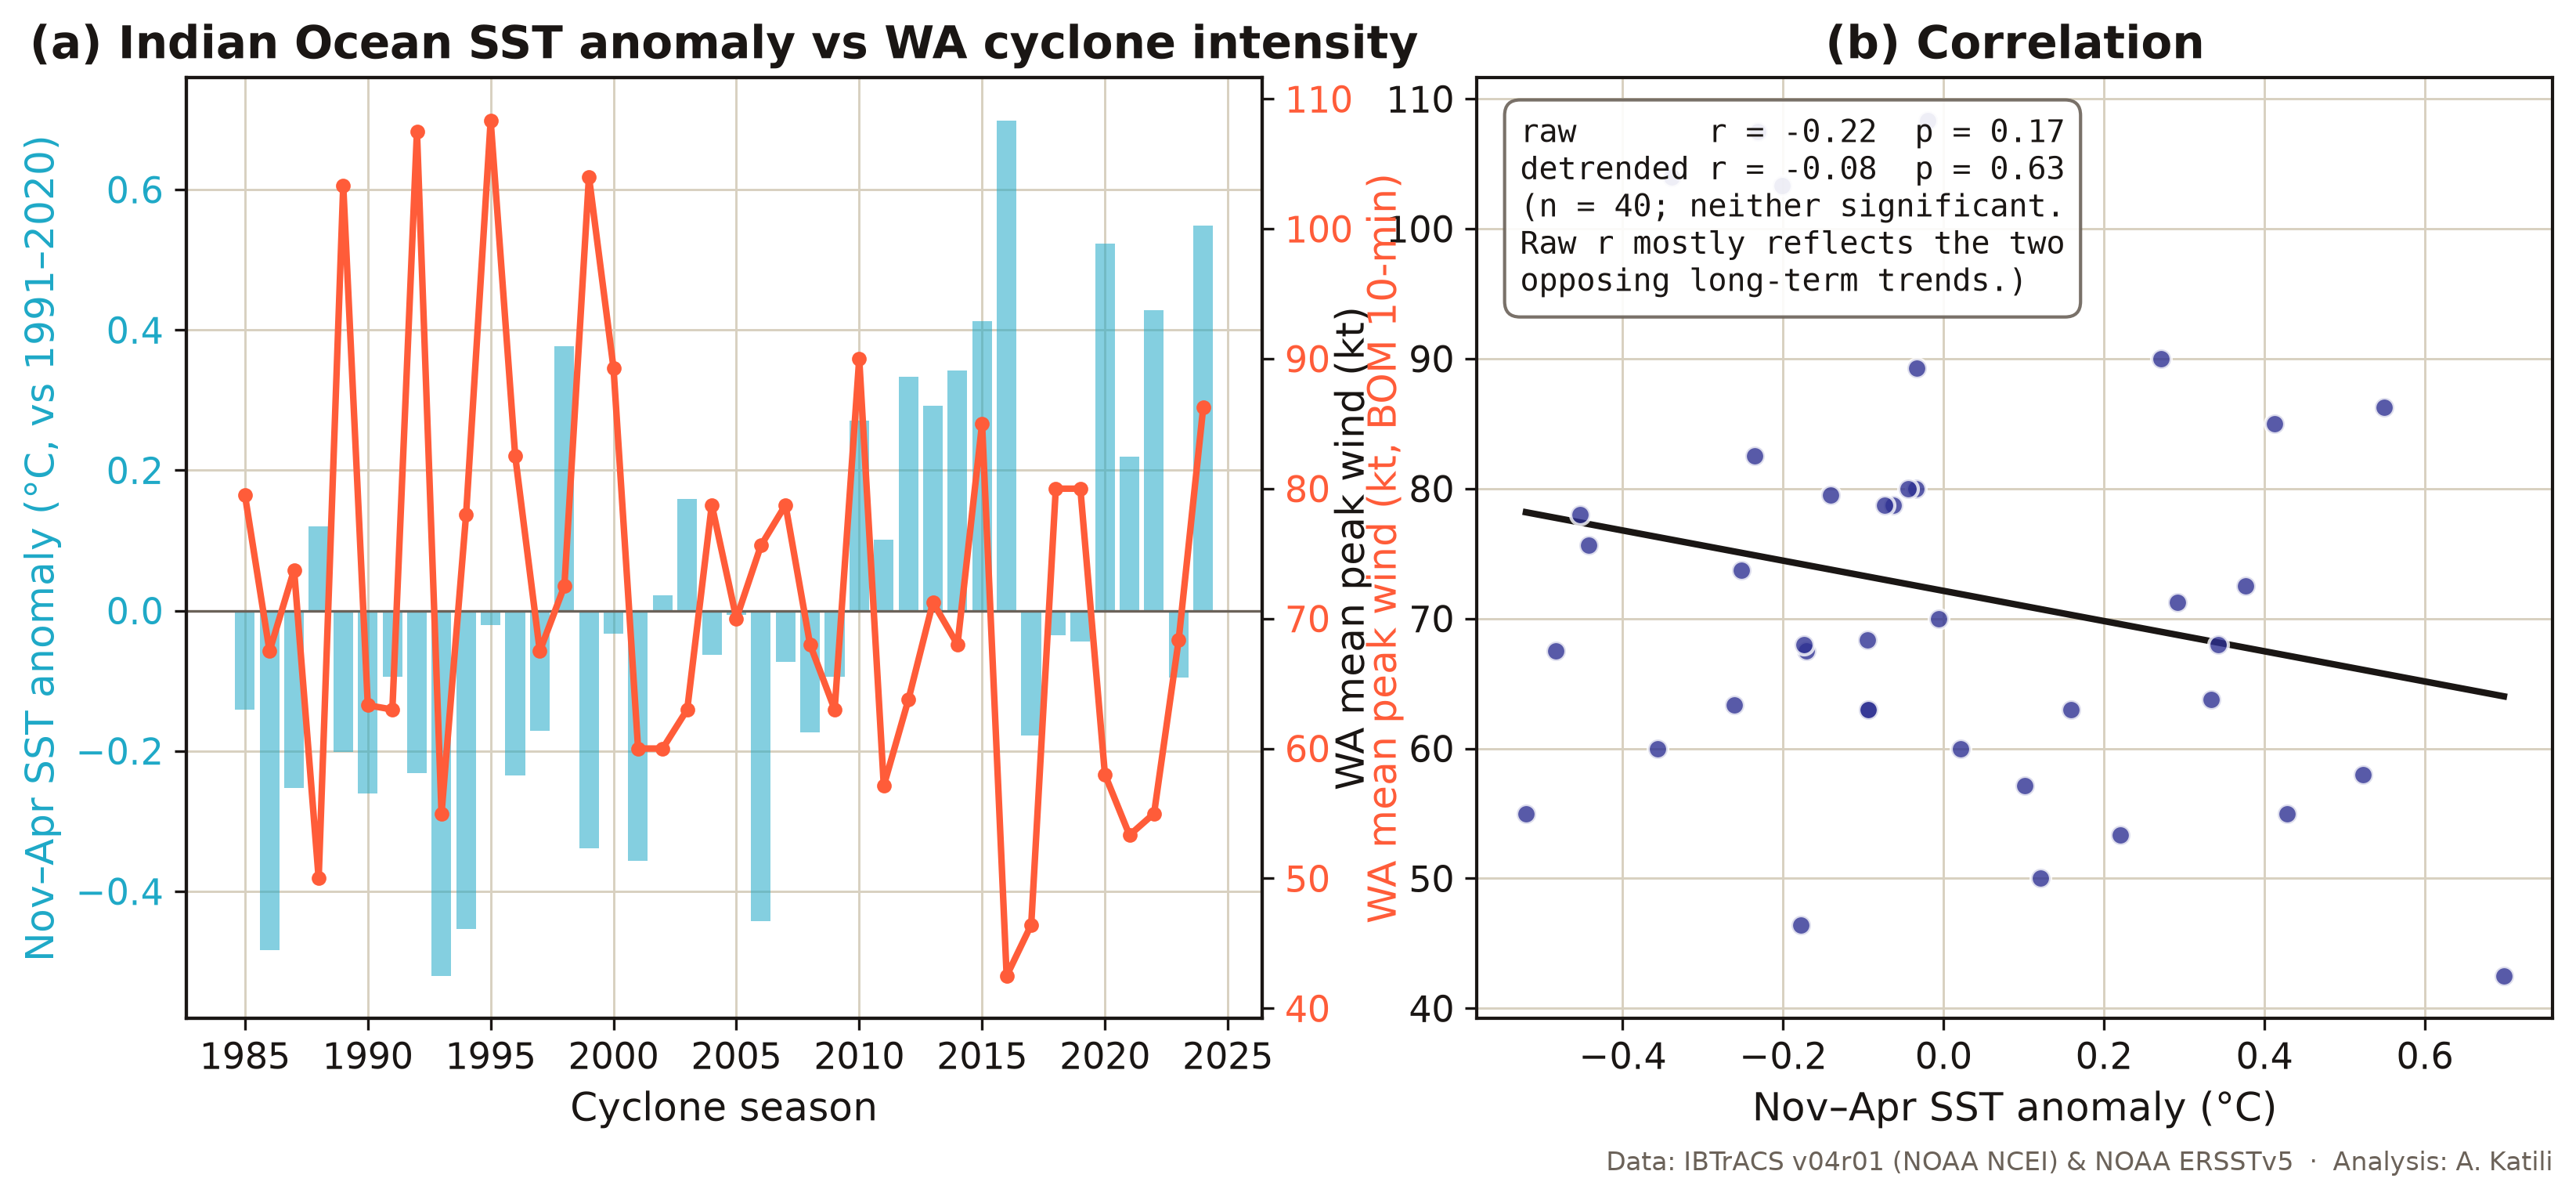

In [6]:
sst = analysis.sst_correlation(storms)
print(f"SST trend: {sst['sst_trend_decade']:+.3f} degC/decade (p={sst['sst_p']:.1e})")
print(f"SST vs WA wind:     raw r={sst['r_wind']:+.2f} (p={sst['p_wind']:.3f})   "
      f"detrended r={sst['r_wind_detrended']:+.2f} (p={sst['p_wind_detrended']:.3f})")
print(f"SST vs WA pressure: raw r={sst['r_pres']:+.2f} (p={sst['p_pres']:.3f})   "
      f"detrended r={sst['r_pres_detrended']:+.2f} (p={sst['p_pres_detrended']:.3f})")
display(Image('charts/06_sst_correlation.png'))

## Findings and AASB S2 implications

Here is the picture. Frequency is flat to slightly down. Strength shows no established trend: the two agency wind records disagree on the direction, neither WA trend is significant, and the cleanest measure (pressure) is borderline toward weaker at best. Rapid intensification looks more common, with the data caveat above. And although the ocean warmed clearly, that warming did not turn into stronger WA cyclones in the record we have, once the shared trends are stripped out.

For AASB S2 physical-risk reporting, which starts for large WA entities from 1 July 2026, the message is this: the historical record backs neither a 'warmer oceans mean stronger storms' claim nor a comforting 'storms are easing' claim for WA. The lack of an established trend is not proof of safety. The energy ceiling has risen, and projections still warn of fewer but possibly more intense systems. So good reporting should rest on forward-looking scenarios, not on assuming the past will repeat, in any direction.

See `README.md` for the full write-up and `INTERVIEW_BRIEF.md` for talking points.

,series,radius_km,slope_kt_decade,ols_p,mk_p,mk_p_tfpw,n_storms,mean_count_per_season,count_slope_decade,count_mk_p
0,lifetime_peak_bom,500,-3.572,0.107,0.263,0.263,NaN,NaN,NaN,NaN
1,near_wa_peak_bom,500,-5.191,0.039,0.087,0.087,NaN,NaN,NaN,NaN
2,radius_check,300,-3.706,0.106,0.152,0.152,164.0,4.100,-0.218,0.357
3,radius_check,500,-3.572,0.107,0.263,0.263,194.0,4.850,-0.276,0.505
4,radius_check,700,-3.571,0.096,0.192,0.192,215.0,5.375,-0.269,0.644


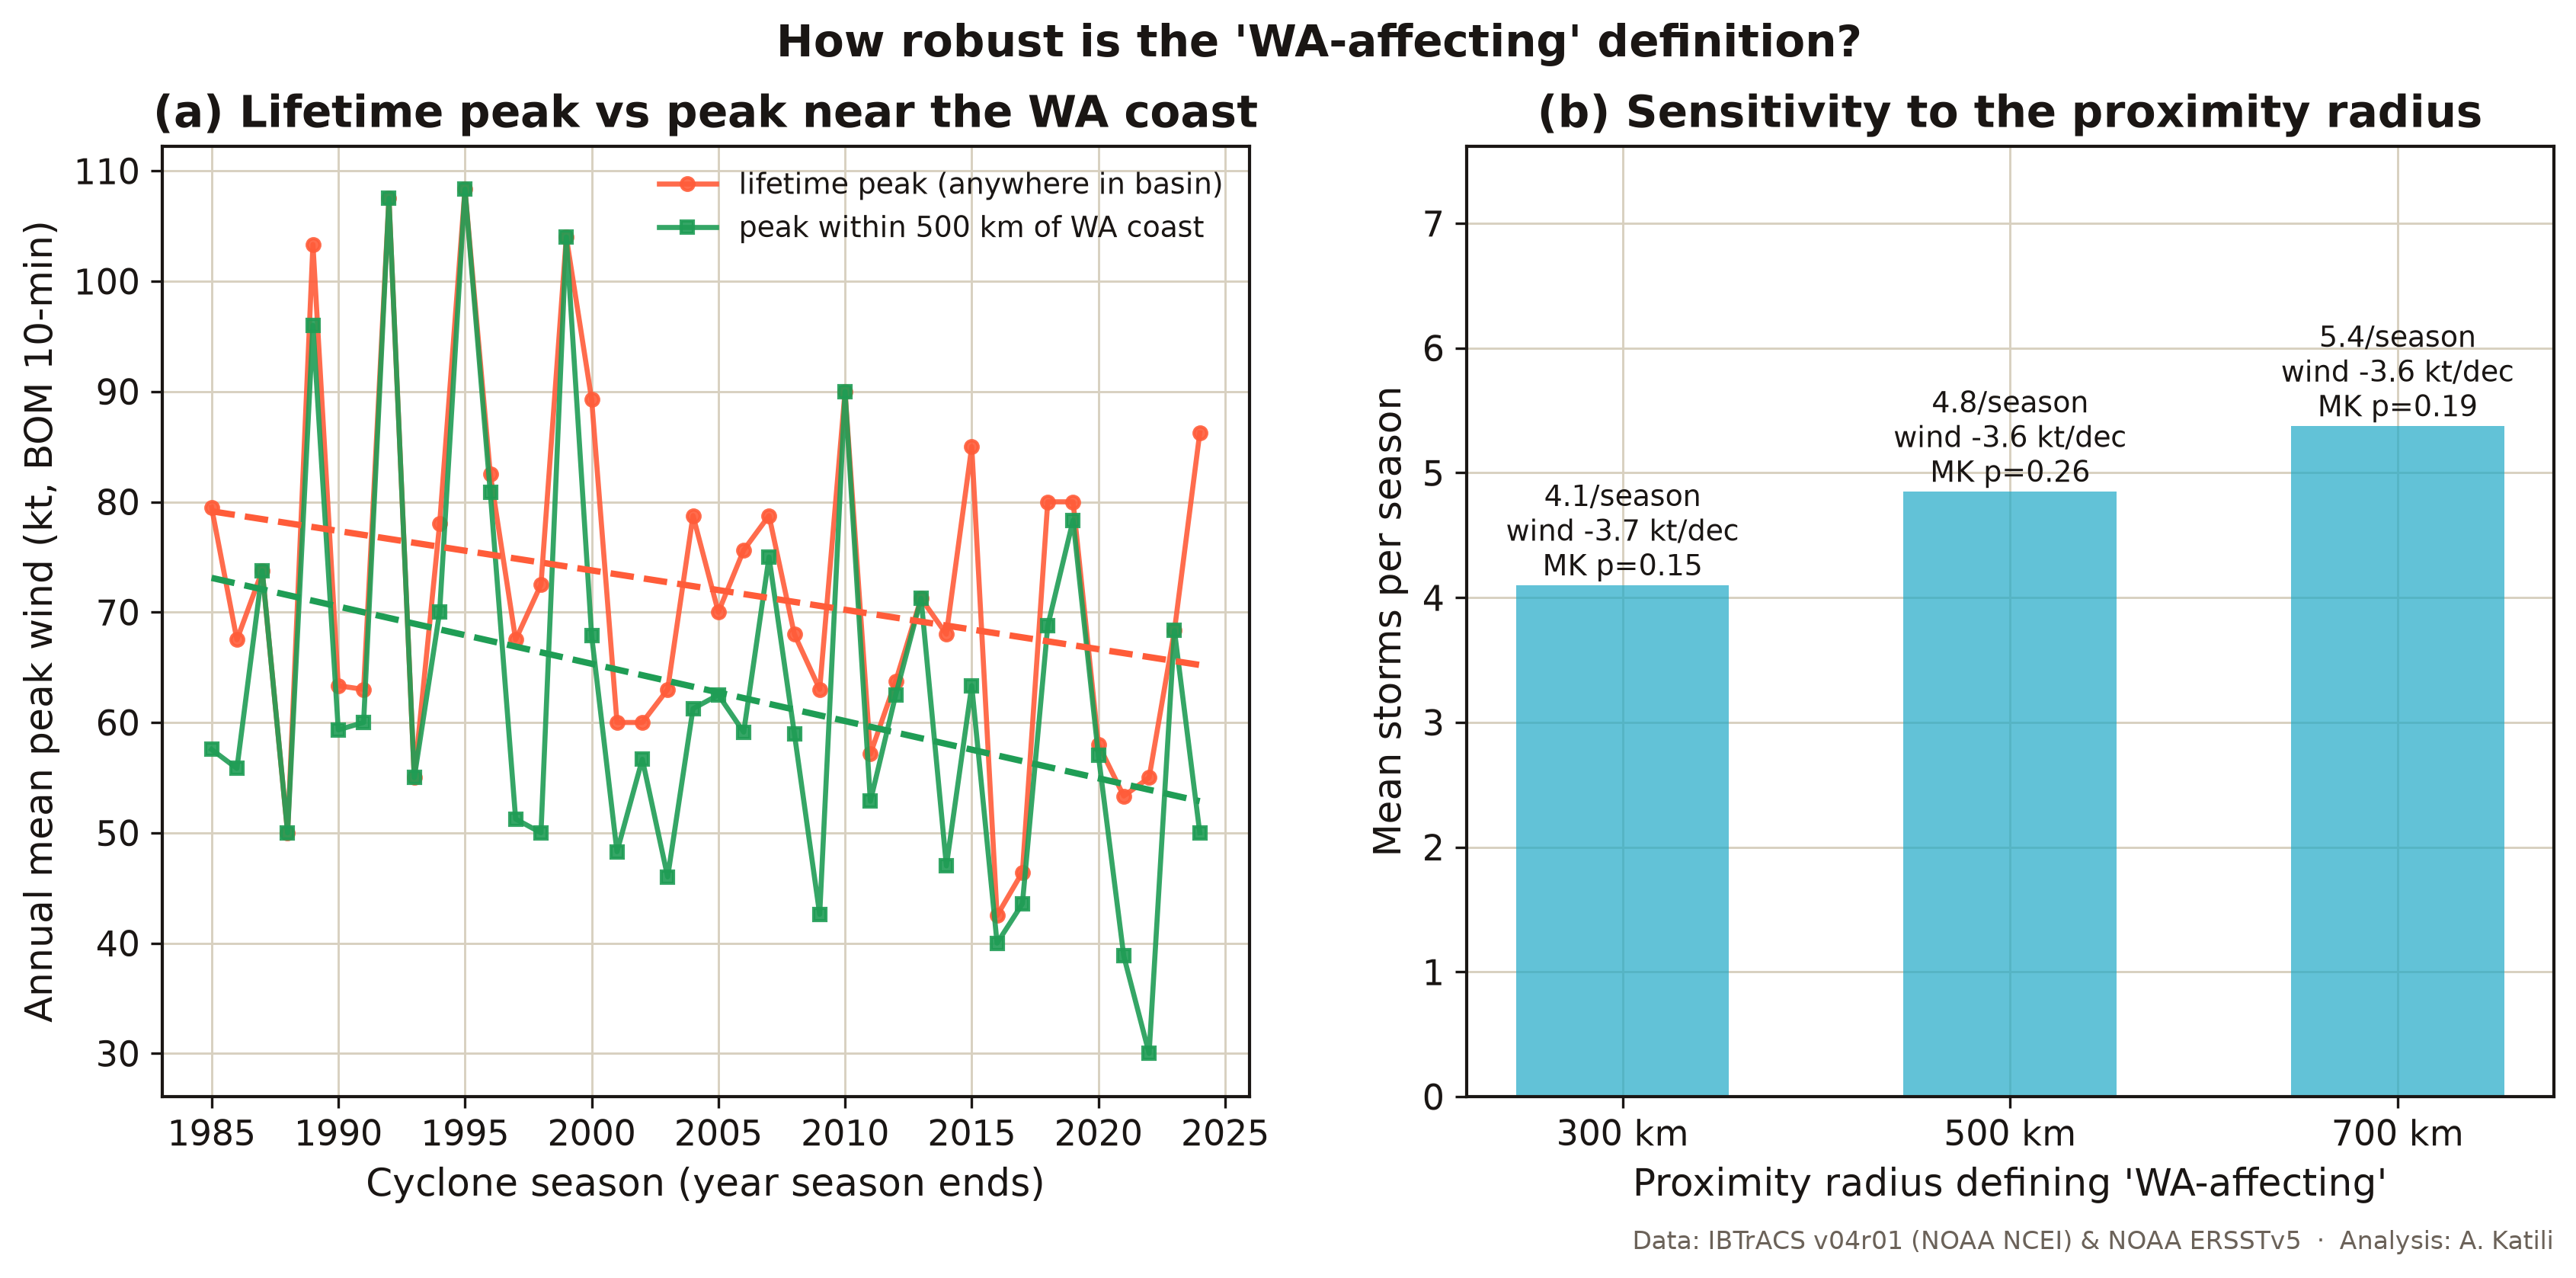

In [7]:
prox_table = analysis.proximity_sensitivity(storms)
display(prox_table.round(3))
display(Image('charts/07_proximity_sensitivity.png'))

## Findings and AASB S2 implications

Here is the picture. Frequency is flat to slightly down. Strength has not risen, and if anything it has eased (clearly so across the basin, only marginally for WA alone). Rapid intensification looks more common, with the data caveat above. And although the ocean warmed clearly, that warming did not turn into stronger WA cyclones in the record we have.

For AASB S2 physical-risk reporting, which starts for large WA entities from 1 July 2026, the message is this: the historical record does not back a simple 'warmer oceans mean stronger storms' claim for WA. But the lack of an observed trend is not proof of safety. The energy ceiling has risen, and projections still warn of fewer but possibly more intense systems. So good reporting should rest on forward-looking scenarios, not on assuming the past will repeat.

See `README.md` for the full write-up and `INTERVIEW_BRIEF.md` for talking points.